# Il Potenziale della SVM: Kernel Lineare vs Kernel RBF
## Modulo 4 - Unita 4.3 - Kernel trick e SVM non lineare

ITS Apulia Digital Academy - ML per il Mondo del Lavoro

Nei notebook precedenti (Iris, Wine) il kernel lineare e il kernel RBF
davano risultati molto simili, perche' quei dataset sono gia quasi
linearmente separabili. Qui usiamo un dataset apposta costruito per
**non** esserlo: due cerchi concentrici. E' il caso da manuale in cui
il kernel trick fa una differenza enorme, non solo qualche punto
percentuale.

---

## 1. Generazione del dataset

Creiamo un dataset sintetico a due cerchi concentrici: la classe 0 sta
dentro, la classe 1 sta fuori. Nessuna retta puo separare questi due
gruppi.

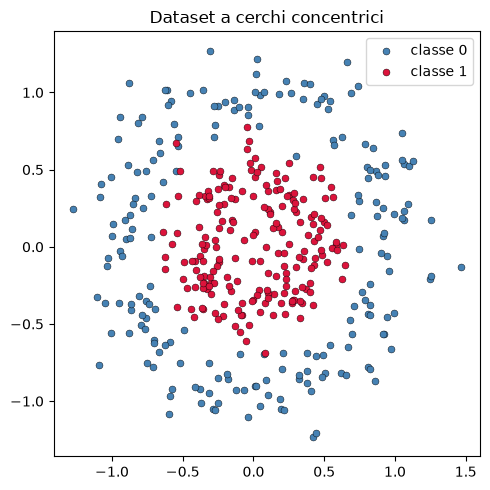

Numero di punti: 400


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

X, y = make_circles(n_samples=400, noise=0.15, factor=0.4, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[y==0,0], X[y==0,1], color="steelblue", s=25, edgecolor="k", linewidth=0.3, label="classe 0")
plt.scatter(X[y==1,0], X[y==1,1], color="crimson", s=25, edgecolor="k", linewidth=0.3, label="classe 1")
plt.title("Dataset a cerchi concentrici")
plt.legend()
plt.tight_layout()
plt.show()

print("Numero di punti:", X.shape[0])

## 2. Split train/test e standardizzazione

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Esempi nel training set:", X_train_s.shape[0])
print("Esempi nel test set:", X_test_s.shape[0])

Esempi nel training set: 300
Esempi nel test set: 100


## 3. SVM con kernel lineare

Proviamo prima il kernel lineare: e' il punto di partenza naturale, ma
su questo dataset ci aspettiamo che fallisca, perche' nessuna retta puo
separare due cerchi concentrici.

In [3]:
modello_lineare = SVC(kernel="linear")
modello_lineare.fit(X_train_s, y_train)

y_pred_lineare = modello_lineare.predict(X_test_s)
accuracy_lineare = accuracy_score(y_test, y_pred_lineare)

print(f"Accuracy kernel lineare: {accuracy_lineare:.3f}")
# Con 2 classi bilanciate, indovinare a caso darebbe circa 0.50:
# un'accuracy vicina a quel valore significa che il modello non ha
# imparato quasi nulla di utile

Accuracy kernel lineare: 0.530


## 4. Visualizziamo il confine di decisione lineare

Disegniamo il confine trovato dal modello lineare sopra i punti del
dataset, per vedere concretamente perche' fallisce.

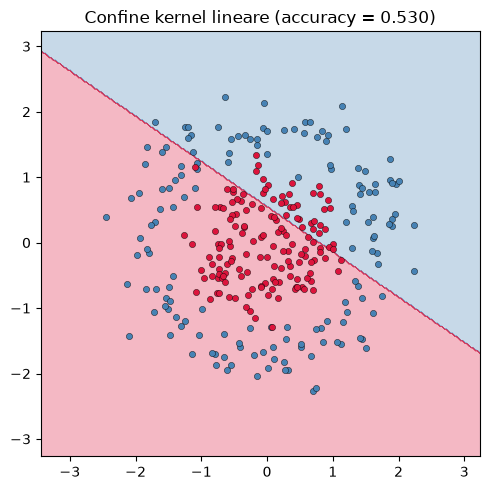

In [4]:
# Griglia di punti che copre il piano di dati GIA standardizzati
xx, yy = np.meshgrid(
    np.linspace(X_train_s[:,0].min()-1, X_train_s[:,0].max()+1, 300),
    np.linspace(X_train_s[:,1].min()-1, X_train_s[:,1].max()+1, 300))

Z = modello_lineare.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["steelblue", "crimson"]))
plt.scatter(X_train_s[y_train==0,0], X_train_s[y_train==0,1], color="steelblue", s=20, edgecolor="k", linewidth=0.3)
plt.scatter(X_train_s[y_train==1,0], X_train_s[y_train==1,1], color="crimson", s=20, edgecolor="k", linewidth=0.3)
plt.title(f"Confine kernel lineare (accuracy = {accuracy_lineare:.3f})")
plt.tight_layout()
plt.show()

# Il confine e' una retta: taglia il dataset a meta' invece di
# distinguere "dentro" da "fuori". Da qui l'accuracy vicina al caso.

## 5. SVM con kernel RBF

Ora proviamo il kernel RBF: misura la similarita' in base alla distanza
tra i punti, quindi puo costruire un confine circolare "naturale" per
questo tipo di dati.

In [5]:
modello_rbf = SVC(kernel="rbf")
modello_rbf.fit(X_train_s, y_train)

y_pred_rbf = modello_rbf.predict(X_test_s)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Accuracy kernel lineare: {accuracy_lineare:.3f}")
print(f"Accuracy kernel RBF:     {accuracy_rbf:.3f}")

Accuracy kernel lineare: 0.530
Accuracy kernel RBF:     0.990


## 6. Visualizziamo il confine di decisione RBF

Stesso tipo di grafico di prima, ma con il modello RBF: qui ci
aspettiamo un confine circolare che segue davvero la forma dei dati.

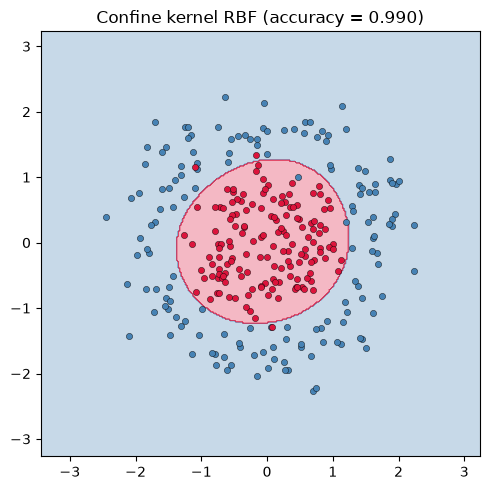

In [6]:
Z_rbf = modello_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z_rbf, alpha=0.3, cmap=ListedColormap(["steelblue", "crimson"]))
plt.scatter(X_train_s[y_train==0,0], X_train_s[y_train==0,1], color="steelblue", s=20, edgecolor="k", linewidth=0.3)
plt.scatter(X_train_s[y_train==1,0], X_train_s[y_train==1,1], color="crimson", s=20, edgecolor="k", linewidth=0.3)
plt.title(f"Confine kernel RBF (accuracy = {accuracy_rbf:.3f})")
plt.tight_layout()
plt.show()

# Il kernel RBF, senza che nessuno gli abbia detto "usa un cerchio",
# trova da solo il confine circolare corretto: e' il kernel trick
# in azione, esattamente come descritto nella slide dell'Unita 4.3

## 7. Matrice di confusione del modello RBF

Confermiamo il risultato con la matrice di confusione.

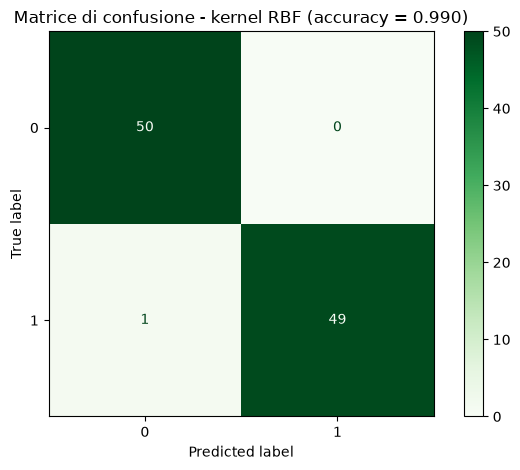

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rbf, cmap="Greens")
plt.title(f"Matrice di confusione - kernel RBF (accuracy = {accuracy_rbf:.3f})")
plt.tight_layout()
plt.show()

## 8. Tuning con GridSearchCV

Anche se il kernel RBF di default gia' funziona benissimo, verifichiamo
con la cross-validation se esiste una combinazione di C e gamma ancora
migliore.

In [8]:
griglia = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.01, 0.1, 1, "scale"],
}

ricerca = GridSearchCV(SVC(kernel="rbf"), griglia, cv=5, scoring="accuracy")
ricerca.fit(X_train_s, y_train)

print("Migliori iperparametri:", ricerca.best_params_)
print(f"Accuracy media in cross-validation: {ricerca.best_score_:.3f}")

accuracy_finale = accuracy_score(y_test, ricerca.best_estimator_.predict(X_test_s))
print(f"Accuracy finale sul test set: {accuracy_finale:.3f}")

Migliori iperparametri: {'C': 1, 'gamma': 'scale'}
Accuracy media in cross-validation: 0.983
Accuracy finale sul test set: 0.990


---
## Conclusioni

| Kernel | Accuracy sul test set |
|---|---|
| Lineare | ~0.53 (praticamente casuale) |
| RBF (default) | ~0.99 |
| RBF (ottimizzato) | ~0.99 |
